# DSC 340 Lab 1: Home Credit Default Risk Logistic Regression

Rothavy Kong, Lucy Synnestvedt

DSC 340 S26  
Project 1: Home Credit Default Risk Logistic Regression 

For this assignment we will use the Home Credit Default Risk Datasets, available on Kaggle and GitHub, to predict whether a loan applicant will default.

Dataset: https://www.kaggle.com/competitions/home-credit-default-risk

## Business Problem Overview

Our bank needs to determine whether a loan applicant is likely to repay or default on a loan. Making inaccurate lending decisions can lead to alot of financial losses from defaults or missed revenue from rejecting reliable borrowers.

To solve the problem, we plan on building a logistic regression model to predict whether loan applicant will default or repay the loan. We believe that this will help us make better decisions when it comes to risk management, help our bank remain stable and maximize our probablistic profit optimization.

In terms of success for our model, we want to catch as many risky loan applicants before we approve their loans to prevent our bank from major financial losses.

To achieve this, we decide to look at a few key metrics.
- Recall: we want to priortizie high recall score because we want to minimize the number of loan applicant who will default.
- AUC and precision: we want to ensure that our model still maintains good overall performance.

Target variable definition
- Target = 0 : Applicant repays the loan
- Target = 1 : Applicant defaults on the loan

## Import Libraries
Before we begin the analysis, we need to import the important libraries 
that we will use throughout our pipeline. bThese are the libraries we will import:

* **Pandas**: data analysis, manipulation, and merging of our four datasets.
* **NumPy**: numerical operations and array handling used in feature engineering.
* **Matplotlib and Seaborn**: data visualization including correlation heatmaps, 
  confusion matrices, and ROC curves.
* **Scikit-learn**: encoding categorical variables, handling missing data via 
  iterative and simple imputation, scaling features, building our logistic 
  regression model, and evaluating performance through cross validation and 
  classification metrics.
* **SciPy**: statistical testing to distinguish between MAR and MCAR 
  missing data patterns.

In [1]:
# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

# Modeling & Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve
)
from sklearn.feature_selection import mutual_info_classif

# Statistics
from scipy import stats

# Settings
import warnings
warnings.filterwarnings('ignore')

## Loading Data
We load the main application dataset and merge three supplementary tables: bureau, previous_application, and installments_payments.

These datasets provide more historical and behavioral information about each applicant, which can improve the predictiveness of our model.

The bureau dataset contains information about applicants’ credit history with other financial institutions. While an applicant’s credit behavior with Home Credit may appear clean, their broader financial behavior across institutions may reveal additional risk signals. This dataset captures important indicators such as the number of active versus closed credit lines, overdue payments with other banks, total outstanding debt, and the length of the applicant’s credit history. Incorporating these features helps provide a more complete view of the applicant’s financial obligations and creditworthiness.

The previous_application dataset includes information about applicants’ past loan applications with Home Credit. These records provide insight into historical interactions between the applicant and the institution, including whether previous applications were approved, refused, or canceled, the reasons for past refusals, and the interest rate tiers assigned to prior loans. These historical outcomes can act as strong predictive signals, as past lending decisions and applicant behavior may correlate with future default risk.

Finally, the installments_payments dataset captures detailed repayment behavior for previously issued loans. It contains transactional level information such as payment timing, the number of days payments were late, and the frequency of missed or delayed payments. These repayment behavior metrics are particularly valuable because they reflect how reliably a customer fulfills their financial obligations once a loan is issued.

By merging these tables, we believe that our model will be able to capture better patterns associated with loan repayment and default risk.

In [2]:
# Main Dataset
df = pd.read_csv("application_train.csv")
main_df = df.copy()

# Bureau table
Bureau_df = pd.read_csv("bureau.csv")
bureau_df = Bureau_df.copy()

# Previous_application table
Previous_df = pd.read_csv("previous_application.csv")
prev_df = Previous_df.copy()

# Installments_payments table
file2 = pd.read_csv("installments_payments.csv")
inst_df = file2.copy()

## Exploratory Data Analysis
We believe that it is very important to conduct Exploratory Data Analysis before any thought of model-building. It is important to explore the dataset first so that we have a better understanding of the problem that we are working with. To do so, we will use Pandas to get the general information from the dataset. To start, we will look at the imbalance of TARGET, shape of the dataset, column names, data types, list of categorical and numerical variables and number of non-null values. This will help us understand the dataset better. 

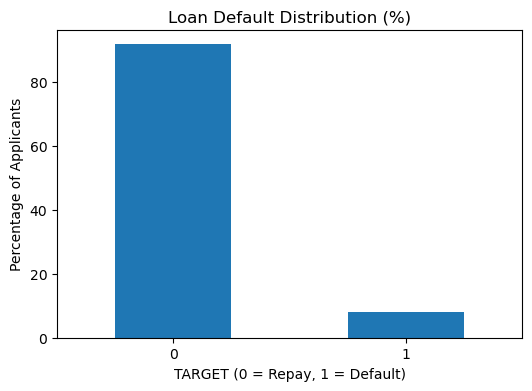

In [3]:
# Loan Default Distribution
percentages = main_df['TARGET'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
percentages.plot(kind='bar')

plt.title('Loan Default Distribution (%)')
plt.xlabel('TARGET (0 = Repay, 1 = Default)')
plt.ylabel('Percentage of Applicants')

plt.xticks(rotation=0)
plt.show()

In [4]:
# Get shape of dataset
print("The shape of main dataset is:",main_df.shape)
print("The shape of bureau table is:",bureau_df.shape)
print("The shape of previous application table is:",prev_df.shape)
print("The shape of installments payments table is:",inst_df.shape)

The shape of main dataset is: (213559, 122)
The shape of bureau table is: (1386571, 17)
The shape of previous application table is: (1670214, 37)
The shape of installments payments table is: (4596894, 8)


In [5]:
# Get summary of missing values %
# Main dataframe
missing_summary_1 = pd.DataFrame({
    "Missing Count": main_df.isnull().sum(),
    "Missing %": main_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_1 = missing_summary_1[missing_summary_1["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for main dataset:", missing_summary_1)

# Bureau table
missing_summary_2 = pd.DataFrame({
    "Missing Count": bureau_df.isnull().sum(),
    "Missing %": bureau_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_2 = missing_summary_2[missing_summary_2["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for bureau table:", missing_summary_2)

# Previous application table
missing_summary_3 = pd.DataFrame({
    "Missing Count": prev_df.isnull().sum(),
    "Missing %": prev_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_3 = missing_summary_3[missing_summary_3["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for previous application table:", missing_summary_3)

# Installments payments table
missing_summary_4 = pd.DataFrame({
    "Missing Count": inst_df.isnull().sum(),
    "Missing %": inst_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_4 = missing_summary_4[missing_summary_4["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for installments payments table:", missing_summary_4)

'Missing summary for main dataset:'

,Missing Count,Missing %
COMMONAREA_MODE,149365,69.940859
COMMONAREA_AVG,149365,69.940859
COMMONAREA_MEDI,149365,69.940859
NONLIVINGAPARTMENTS_MODE,148328,69.455279
NONLIVINGAPARTMENTS_AVG,148328,69.455279
NONLIVINGAPARTMENTS_MEDI,148328,69.455279
FONDKAPREMONT_MODE,146107,68.415286
LIVINGAPARTMENTS_MEDI,146066,68.396087
LIVINGAPARTMENTS_AVG,146066,68.396087
LIVINGAPARTMENTS_MODE,146066,68.396087


'Missing summary for bureau table:'

,Missing Count,Missing %
AMT_ANNUITY,980236,70.694973
AMT_CREDIT_MAX_OVERDUE,910492,65.665011


'Missing summary for previous application table:'

,Missing Count,Missing %
RATE_INTEREST_PRIVILEGED,1664263,99.643698
RATE_INTEREST_PRIMARY,1664263,99.643698
AMT_DOWN_PAYMENT,895844,53.636480
RATE_DOWN_PAYMENT,895844,53.636480


'Missing summary for installments payments table:'

,Missing Count,Missing %


## Drop Columns with missing data
In this step, we will handle missing data in our datasets by dropping columns with a missing percentage above 50%. According to the summary table above, only the Main dataset, Bureau table and Previous Application table have missing data percentages above this threshold.

We decided to handle missing data by only dropping columns at this stage because we want to examine multicollinearity and perform feature engineering before merging the datasets. We do not want to work with data that we already know has a missing percentage above 50%, which is why we chose to drop these columns and not do any imputation yet to avoid data leakage. Later on, after we split the data into training and test sets, we will handle the remaining missing data through imputation.

In [6]:
# Drop columns with missing data > 50%
# Main Dataset
threshold = len(main_df) * 0.5
main_df = main_df.dropna(axis=1, thresh=threshold)

# Bureau Dataset
threshold = len(bureau_df) * 0.5
bureau_df = bureau_df.dropna(axis=1, thresh=threshold)

# Previous application Dataset
threshold = len(prev_df) * 0.5
prev_df = prev_df.dropna(axis=1, thresh=threshold)

## Variable Selection Process for Main Dataset
In this step, we will look at our main dataset which is the applicaton_train dataset and we will look at which variables to choose and which features we should engineer to further increase the predictivness of our model.

Before choosing the variables for our model building, we decide to ask a few important questions about the loan applicant.  

1. Can they afford the loan?
2. Are they financially stable?
3. Have they struggled with credit before?
4. Are they showing risky payment behavior in the past?
5. Who are they demographically?

To answer these questions, we decided to look into each variables description that will help us answer the questions better and categorize each variables into: Demographic Characteristics, Employment and Income Stability, Financial Behavior and Credit History, Application and Administrative Information, Loan and Contract Characteristics, Housing and Asset Ownership, Geographic Risk Indicators.

These are some of the columns that we consider using in our model. 

Demographic Characteristics
- NAME_EDUCATION_TYPE
- DAYS_BIRTH
- CNT_FAM_MEMBERS
- NAME_FAMILY_STATUS

Employment and Income Stability
- DAYS_EMPLOYED
- NAME_INCOME_TYPE

Financial Behavior and Credit History
- AMT_REQ_CREDIT_BUREAU_YEAR
- DEF_60_CNT_SOCIAL_CIRCLE
- EXT_SOURCE_2
- EXT_SOURCE_3

Application and Administrative Information
- DAYS_REGISTRATION
- DAYS_ID_PUBLISH
- DAYS_LAST_PHONE_CHANGE

Loan and Contract Characteristics
- NAME_CONTRACT_TYPE
- ANNUITY_INCOME_RATIO
- LOAN_INCOME_RATIO

Housing and Asset Ownership
- FLAG_OWN_REALTY
- FLAG_OWN_CAR
- NAME_HOUSING_TYPE

Geographic Risk Indicators
- REGION_RATING_CLIENT
- REGION_RATING_CLIENT_W_CITY

## Multicollinearity and Feature Engineering
We will look at multicollinearity between features in each dataset before merging. We believe it is important to handle multicollinearity because when two variables contain redundant information, these features might introduce noise and inflate the variance of our coefficients and make them unstable, difficult to intepret. So to address this, we create a correlation matrix for each table and identify pairs above a 65% correlation threshold. Rather than simply dropping one of the correlated features, we engineer new features that would best capture the information from both variables before dropping the original.

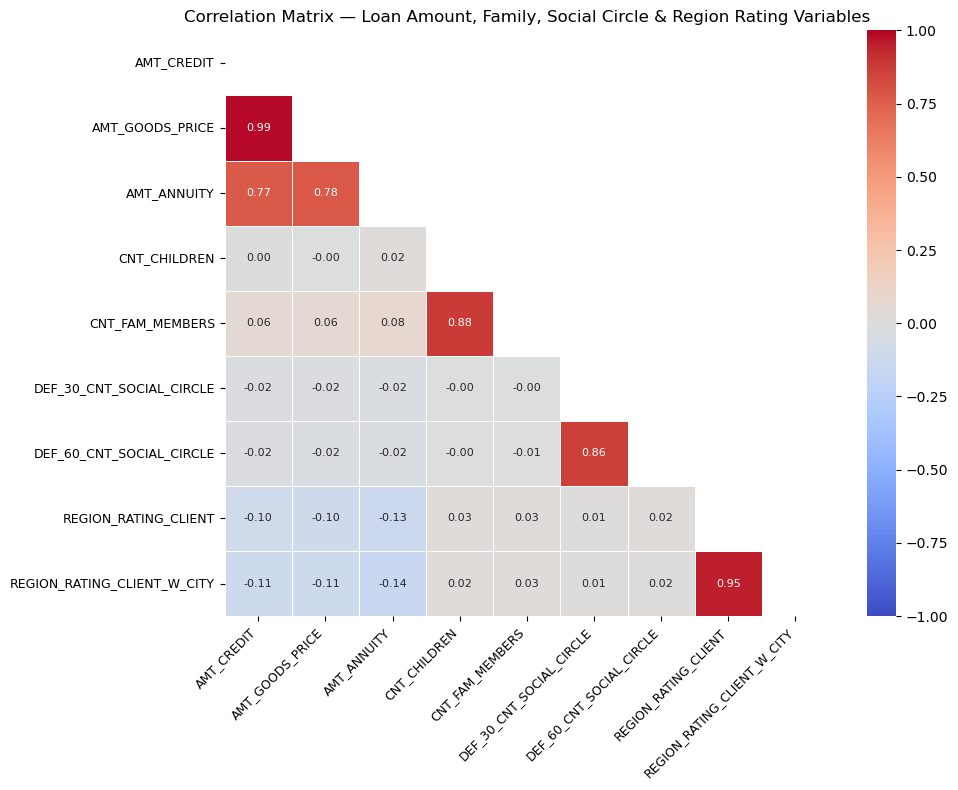

  Variables with Correlation ABOVE 65%
AMT_GOODS_PRICE & AMT_CREDIT
→ Correlation: 0.99 (positive)

REGION_RATING_CLIENT_W_CITY & REGION_RATING_CLIENT
→ Correlation: 0.95 (positive)

CNT_FAM_MEMBERS & CNT_CHILDREN
→ Correlation: 0.88 (positive)

DEF_60_CNT_SOCIAL_CIRCLE & DEF_30_CNT_SOCIAL_CIRCLE
→ Correlation: 0.86 (positive)

AMT_ANNUITY & AMT_GOODS_PRICE
→ Correlation: 0.78 (positive)

AMT_ANNUITY & AMT_CREDIT
→ Correlation: 0.77 (positive)

  Total highly correlated pairs found: 6


In [7]:
# Main dataset Correlation matrix
corr = main_df[['AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY',
                 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
                 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
                 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8},
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix — Loan Amount, Family, Social Circle & Region Rating Variables")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

After looking the correlation matrix, we identified 6 highly correlated pairs 
above our 65% threshold. Here is what we decide to do:

There is a 99% correlation between AMT_GOODS_PRICE and AMT_CREDIT, a 78% correlation between AMT_ANNUITY and AMT_GOODS_PRICE, and a 77% correlation between AMT_ANNUITY and AMT_CREDIT. We decided to drop all three raw variables to resolve the multicollinearity. In their place, we engineered two new features ANNUITY_INCOME_RATIO and LOAN_INCOME_RATIO which capture affordability relative to the applicant's income rather than raw dollar amounts.

There is an 88% correlation between CNT_CHILDREN and CNT_FAM_MEMBERS. We decided to keep CNT_FAM_MEMBERS over CNT_CHILDREN because CNT_FAM_MEMBERS takes into account all members of the family and will give more detail to the model.

There is an 86% correlation between DEF_30_CNT_SOCIAL_CIRCLE and DEF_60_CNT_SOCIAL_CIRCLE. We decided to keep DEF_60_CNT_SOCIAL_CIRCLE and drop DEF_30_CNT_SOCIAL_CIRCLE because the 60-day window captures more serious and sustained 
default behavior, which is a stronger signal for credit risk.

There is a 95% correlation between REGION_RATING_CLIENT and REGION_RATING_CLIENT_W_CITY. We decided to keep REGION_RATING_CLIENT_W_CITY because it has a higher granularity. Having a higher granularity will give more detail to the model.

In [8]:
# Feature engineering
main_df["ANNUITY_INCOME_RATIO"] = main_df["AMT_ANNUITY"]/main_df["AMT_INCOME_TOTAL"]
main_df["LOAN_INCOME_RATIO"] = main_df["AMT_CREDIT"]/main_df["AMT_INCOME_TOTAL"]

In [9]:
# Drop features 
main_df = main_df.drop(columns=[
    'AMT_GOODS_PRICE',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'CNT_CHILDREN',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'REGION_RATING_CLIENT'
])

In [10]:
# Final Variable Selection for main dataset
application_df = main_df[['SK_ID_CURR','TARGET','NAME_EDUCATION_TYPE','ANNUITY_INCOME_RATIO',
'LOAN_INCOME_RATIO','DAYS_REGISTRATION','DAYS_ID_PUBLISH','DAYS_LAST_PHONE_CHANGE',
'AMT_REQ_CREDIT_BUREAU_YEAR','DEF_60_CNT_SOCIAL_CIRCLE','DAYS_EMPLOYED','DAYS_BIRTH',
'CNT_FAM_MEMBERS','REGION_RATING_CLIENT_W_CITY','EXT_SOURCE_2','EXT_SOURCE_3','NAME_CONTRACT_TYPE','FLAG_OWN_REALTY','FLAG_OWN_CAR',
'NAME_INCOME_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','CODE_GENDER']]

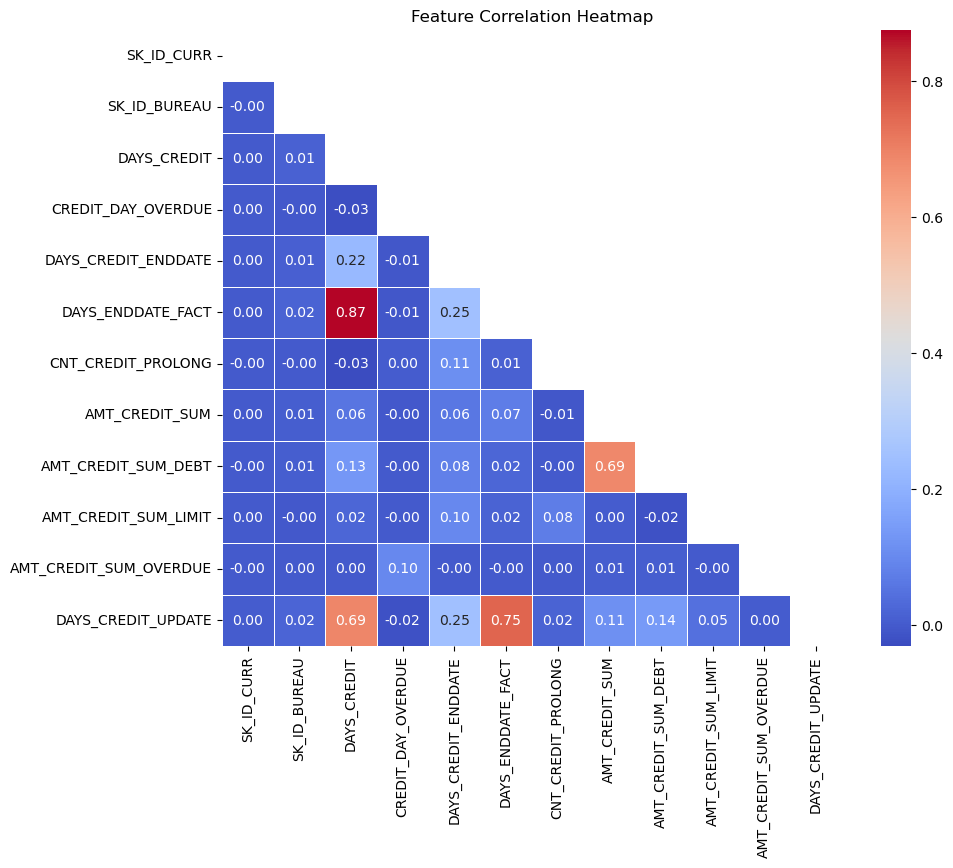

  Variables with Correlation ABOVE 65%
DAYS_ENDDATE_FACT & DAYS_CREDIT
→ Correlation: 0.87 (positive)

DAYS_CREDIT_UPDATE & DAYS_ENDDATE_FACT
→ Correlation: 0.75 (positive)

DAYS_CREDIT_UPDATE & DAYS_CREDIT
→ Correlation: 0.69 (positive)

AMT_CREDIT_SUM_DEBT & AMT_CREDIT_SUM
→ Correlation: 0.69 (positive)

  Total highly correlated pairs found: 4


In [11]:
# Bureau Correlation matrix
corr = bureau_df.select_dtypes(include='number').corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

According to the correlation matrix above, we see there are 4 highly correlated pairs found. Here is a breakdown of each highly correlated pairs and how we plan to handle them.

- Days Credit and Days Enddate Fact
There is a 88% correlation between these features. So we decide to engineer a new feature CREDIT_DURATION which is about how long the credit actually lasted. We believe this single feature captures the relationship between both and is more interpretable than either alone. We decide to drop the original features.

- Days Enddate Fact and Days Credit Update
There is a 75% correlation between these features. So we decide to engineer a new feature which is how long ago was this credit updated relative to when it closed. We see that the large gap here could indicate a stale or disputed record which suggests meaningful signal for default risk. We decide to drop the original features.

- Amt Credit Sum and Amt Credit Sum Debt
There is a 68% correlation between these features so we decide to engineer a new feature Debt utilization ratio which is about how much of the credit is still unpaid. The other feature is CREDIT_REMAINING which is about remaining credi availability. We then decide to drop the original features.

- Days Credit and Days Credit Update
There is a 69% correlation between these two variables. We decide to engineer a new feaature DAYS_SINCE_OPEN_TO_UPDATE which is how recently was this credit record touched relative to when it opened. We then drop the original features.

In [12]:
# Feature Engineering
bureau_df['CREDIT_DURATION'] = bureau_df['DAYS_ENDDATE_FACT'] - bureau_df['DAYS_CREDIT']

bureau_df['DAYS_SINCE_CLOSE_TO_UPDATE'] = bureau_df['DAYS_CREDIT_UPDATE'] - bureau_df['DAYS_ENDDATE_FACT']

bureau_df['DEBT_UTILIZATION'] = bureau_df['AMT_CREDIT_SUM_DEBT'] / (bureau_df['AMT_CREDIT_SUM'] + 1)

bureau_df['CREDIT_REMAINING'] = bureau_df['AMT_CREDIT_SUM'] - bureau_df['AMT_CREDIT_SUM_DEBT']

bureau_df['DAYS_SINCE_OPEN_TO_UPDATE'] = bureau_df['DAYS_CREDIT_UPDATE'] - bureau_df['DAYS_CREDIT']

In [13]:
# Drop features
bureau_df = bureau_df.drop(columns=[
    'DAYS_CREDIT',
    'DAYS_ENDDATE_FACT',
    'DAYS_CREDIT_UPDATE',
    'AMT_CREDIT_SUM',
    'AMT_CREDIT_SUM_DEBT'
])

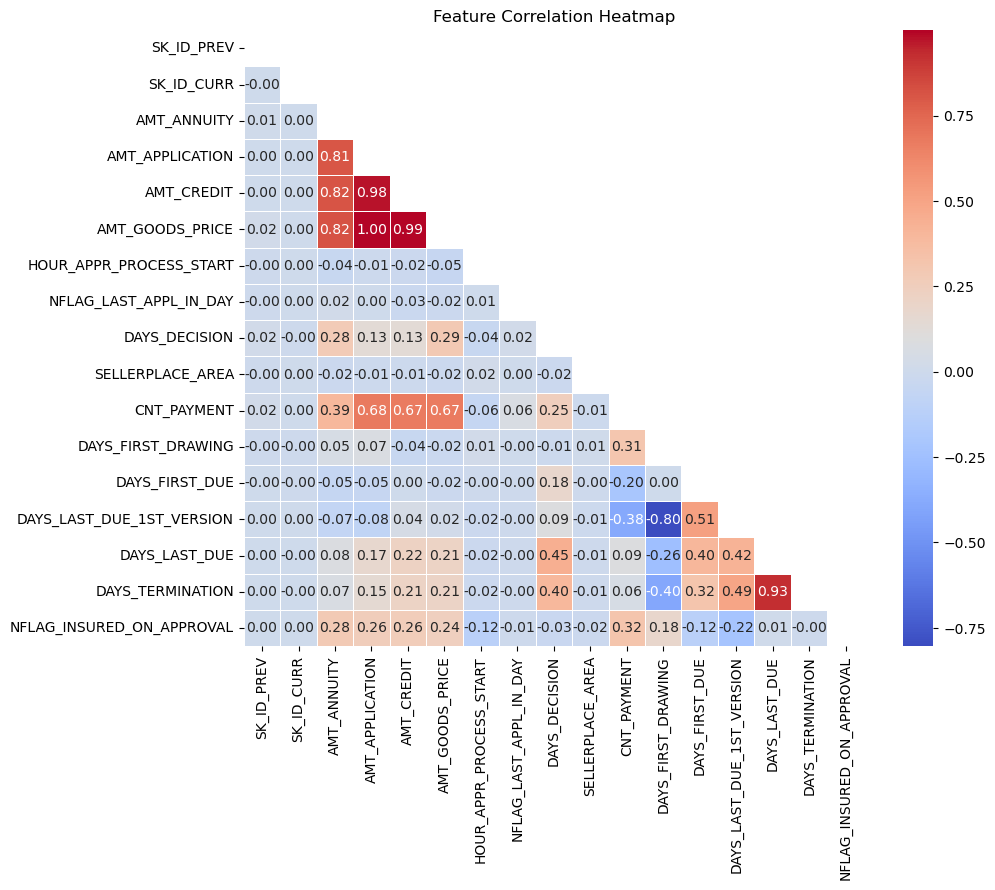

  Variables with Correlation ABOVE 65%
AMT_GOODS_PRICE & AMT_APPLICATION
→ Correlation: 1.00 (positive)

AMT_GOODS_PRICE & AMT_CREDIT
→ Correlation: 0.99 (positive)

AMT_CREDIT & AMT_APPLICATION
→ Correlation: 0.98 (positive)

DAYS_TERMINATION & DAYS_LAST_DUE
→ Correlation: 0.93 (positive)

AMT_GOODS_PRICE & AMT_ANNUITY
→ Correlation: 0.82 (positive)

AMT_CREDIT & AMT_ANNUITY
→ Correlation: 0.82 (positive)

AMT_APPLICATION & AMT_ANNUITY
→ Correlation: 0.81 (positive)

CNT_PAYMENT & AMT_APPLICATION
→ Correlation: 0.68 (positive)

CNT_PAYMENT & AMT_CREDIT
→ Correlation: 0.67 (positive)

CNT_PAYMENT & AMT_GOODS_PRICE
→ Correlation: 0.67 (positive)

DAYS_LAST_DUE_1ST_VERSION & DAYS_FIRST_DRAWING
→ Correlation: -0.80 (negative)

  Total highly correlated pairs found: 11


In [14]:
# Previous Application Correlation matrix
corr = prev_df.select_dtypes(include='number').corr()  # ← renamed to corr_prev to avoid collision with bureau corr

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

Handle Multicollinearity
Group 1: AMT_CREDIT, AMT_APPLICATION, AMT_GOODS_PRICE (0.98–1.00)
These are nearly identical so we decide to drop two and keep one. AMT_CREDIT is usually the most meaningful for credit risk modeling since it's the actual loan amount granted. Drop AMT_APPLICATION and AMT_GOODS_PRICE.

Group 2: AMT_ANNUITY + CNT_PAYMENT (0.67–0.82)
These correlate with the AMT group above. Since we have already kept AMT_CREDIT, we decide to drop AMT_ANNUITY and engineer a new feature like AMT_ANNUITY / AMT_CREDIT (annuity rate), which captures more information than either alone.

Group 3: DAYS_TERMINATION & DAYS_LAST_DUE (0.93)
Keep one — DAYS_LAST_DUE is more interpretable. Drop DAYS_TERMINATION.

Group 4: DAYS_LAST_DUE_1ST_VERSION & DAYS_FIRST_DRAWING (-0.80)
Strong negative correlation is still multicollinearity. Consider dropping DAYS_FIRST_DRAWING or engineering a duration feature like DAYS_LAST_DUE_1ST_VERSION - DAYS_FIRST_DRAWING to capture the loan term span.

In [15]:
# Feature Engineering
# Group 2 
prev_df["AMT_ANNUITY_RATE"]=prev_df["AMT_ANNUITY"]/prev_df["AMT_CREDIT"]

# Group 3 
prev_df['LOAN_TERM_SPAN'] = prev_df['DAYS_LAST_DUE_1ST_VERSION'] - prev_df['DAYS_FIRST_DRAWING']

In [16]:
# Drop features
prev_df.drop(columns=["AMT_APPLICATION", "AMT_GOODS_PRICE"], inplace=True)
prev_df.drop(columns=["AMT_ANNUITY"], inplace=True)
prev_df = prev_df.drop(columns=['DAYS_LAST_DUE_1ST_VERSION', 'DAYS_FIRST_DRAWING'], errors='ignore')

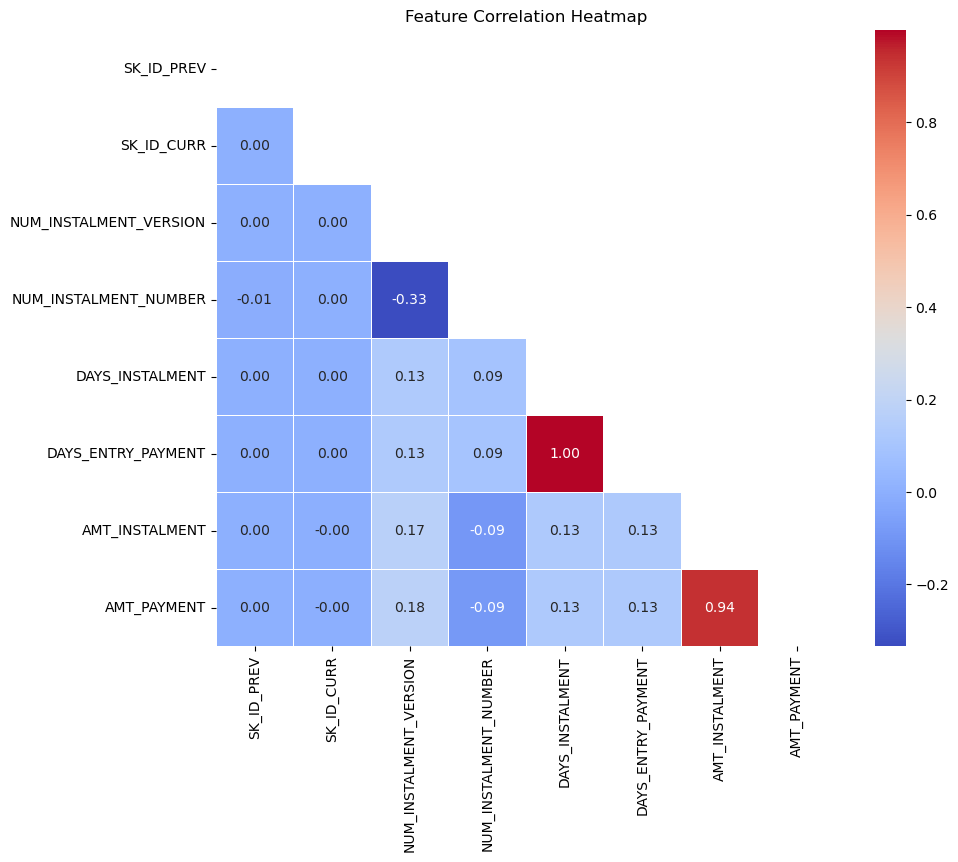

  Variables with Correlation ABOVE 65%
DAYS_ENTRY_PAYMENT & DAYS_INSTALMENT
→ Correlation: 1.00 (positive)

AMT_PAYMENT & AMT_INSTALMENT
→ Correlation: 0.94 (positive)

  Total highly correlated pairs found: 2


In [17]:
# Installments payments Correlation matrix
corr = inst_df.select_dtypes(include='number').corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

After looking at the correlation matrix, we see that DAYS_ENTRY_PAYMENT and DAYS_INSTALMENT are 100% correlated. So we decide to enginner a new feature DAYS_PAYMENT_DELAY and drop the two features. We believe this new feature is good at capturing how late or early the customer paid. If there are alot of late payments, then this suggests high risk of Default.

As for AMT_PAYMENT and AMT_INSTALMENT which are 94% correlated. We decide to engineer two new features PAYMENT_RATIO and PAYMENT_DIFF to capture how much of the required payment was actually paid. Then we drop AMT_PAYMENT and AMT_INSTALMENT.

In [18]:
# Feature engineering
inst_df['DAYS_PAYMENT_DELAY'] = inst_df['DAYS_ENTRY_PAYMENT'] - inst_df['DAYS_INSTALMENT']
inst_df['PAYMENT_RATIO'] = inst_df['AMT_PAYMENT'] / (inst_df['AMT_INSTALMENT'] + 1)
inst_df['PAYMENT_DIFF']  = inst_df['AMT_PAYMENT'] - inst_df['AMT_INSTALMENT']

In [19]:
# Drop features
inst_df.drop(columns=['DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT'], inplace=True)
inst_df.drop(columns=['AMT_PAYMENT', 'AMT_INSTALMENT'], inplace=True)

## Merging Datasets and Aggregating

In [20]:
# Bureau Dataset
bureau_agg = bureau_df.groupby('SK_ID_CURR').agg(

    # --- Credit Count & Activity ---
    BUREAU_CREDIT_COUNT          = ('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT          = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT          = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),

    # --- Overdue ---
    BUREAU_OVERDUE_MEAN          = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_OVERDUE_MAX           = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_OVERDUE_SUM           = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),

    # --- Debt Utilization (replaces AMT_CREDIT_SUM & AMT_CREDIT_SUM_DEBT) ---
    BUREAU_DEBT_UTIL_MEAN        = ('DEBT_UTILIZATION', 'mean'),
    BUREAU_DEBT_UTIL_MAX         = ('DEBT_UTILIZATION', 'max'),

    # --- Credit Duration (replaces DAYS_CREDIT & DAYS_ENDDATE_FACT) ---
    BUREAU_DURATION_MEAN         = ('CREDIT_DURATION', 'mean'),
    BUREAU_DURATION_MAX          = ('CREDIT_DURATION', 'max'),

    # --- Credit Remaining (replaces AMT_CREDIT_SUM & AMT_CREDIT_SUM_DEBT) ---
    BUREAU_CREDIT_REMAINING_MEAN = ('CREDIT_REMAINING', 'mean'),
    BUREAU_CREDIT_REMAINING_SUM  = ('CREDIT_REMAINING', 'sum'),

    # --- Prolongations ---
    BUREAU_PROLONG_SUM           = ('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_PROLONG_MAX           = ('CNT_CREDIT_PROLONG', 'max'),

    # --- Days Since Close to Update (replaces DAYS_ENDDATE_FACT & DAYS_CREDIT_UPDATE) ---
    BUREAU_DAYS_SINCE_CLOSE_MEAN = ('DAYS_SINCE_CLOSE_TO_UPDATE', 'mean'),

    # --- Days Since Open to Update (replaces DAYS_CREDIT & DAYS_CREDIT_UPDATE) ---
    BUREAU_DAYS_SINCE_OPEN_MEAN  = ('DAYS_SINCE_OPEN_TO_UPDATE', 'mean'),

).reset_index()

In [21]:
inst_with_prev = inst_df.merge(
    prev_df[['SK_ID_PREV','CODE_REJECT_REASON','NAME_YIELD_GROUP','NAME_CONTRACT_STATUS',
             'DAYS_LAST_DUE']],
    on='SK_ID_PREV',
    how='left'
)

inst_with_prev.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_PAYMENT_DELAY', 'PAYMENT_RATIO',
       'PAYMENT_DIFF', 'CODE_REJECT_REASON', 'NAME_YIELD_GROUP',
       'NAME_CONTRACT_STATUS', 'DAYS_LAST_DUE'],
      dtype='object')

In [ ]:
# Aggregate installment_table up to SK_ID_CURR level
inst_agg = inst_with_prev.groupby('SK_ID_CURR').agg(
    INST_NUM_PREV_LOANS     = ('SK_ID_PREV', 'nunique'),
    INST_MAX_VERSION        = ('NUM_INSTALMENT_VERSION', 'max'),
    INST_MAX_NUMBER         = ('NUM_INSTALMENT_NUMBER', 'max'),
    INST_AVG_DELAY          = ('DAYS_PAYMENT_DELAY', 'mean'),
    INST_MAX_DELAY          = ('DAYS_PAYMENT_DELAY', 'max'),
    INST_MIN_DELAY          = ('DAYS_PAYMENT_DELAY', 'min'),
    INST_NUM_LATE           = ('DAYS_PAYMENT_DELAY', lambda x: (x > 0).sum()),
    INST_NUM_EARLY          = ('DAYS_PAYMENT_DELAY', lambda x: (x < 0).sum()),
    INST_AVG_PAYMENT_RATIO  = ('PAYMENT_RATIO', 'mean'),
    INST_MIN_PAYMENT_RATIO  = ('PAYMENT_RATIO', 'min'),
    INST_NUM_UNDERPAID      = ('PAYMENT_RATIO', lambda x: (x < 1).sum()),
    INST_AVG_PAYMENT_DIFF   = ('PAYMENT_DIFF', 'mean'),
    INST_MIN_PAYMENT_DIFF   = ('PAYMENT_DIFF', 'min'),
    INST_MAX_PAYMENT_DIFF   = ('PAYMENT_DIFF', 'max'),
    INST_NUM_RECORDS        = ('SK_ID_PREV', 'count'),
    PREV_REJECT_COUNT       = ('CODE_REJECT_REASON', lambda x: (x != 'XAP').sum()),
    PREV_APPROVED_COUNT     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELLED_COUNT    = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_APPROVAL_RATE      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').mean()),
    PREV_YIELD_GROUP_MODE   = ('NAME_YIELD_GROUP', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'),  # fixed
    PREV_DAYS_LAST_DUE_MAX  = ('DAYS_LAST_DUE', 'max')
).reset_index()

inst_agg.columns

In [ ]:
# All tables are at SK_ID_CURR level — merge into main table
merged_main_bureau = application_df.merge(bureau_agg,on='SK_ID_CURR', how='left')
merged_df = merged_main_bureau.merge(inst_agg,on='SK_ID_CURR', how='left')

merged_df.columns

### Aggregation Summary

MAX — When the Worst Case Matters (Risk Indicators)

The single worst observation is more meaningful than the average. When considering loaning, one catastrophic event is more predictive than typical behavior.

MEAN — When Typical Behavior Matters

The average captures consistent patterns across all observations rather than being skewed by one extreme event.

MIN — When the Most Recent or Best Case Matters

For days-based features, MIN gives you the most recent event since days are negative numbers (closer to 0 = more recent).  Dataset is 

SUM — When Total Exposure Matters

Cumulative totals capture overall financial burden regardless of how many loans exist.

COUNT/NUNIQUE — When Frequency or Diversity Matters

How many times something happened or how many distinct entities exist.

RATE/RATIO — When Proportion Matters More Than Raw Count

Normalizes for the number of observations so applicants with more history aren't unfairly penalized.

## Handling Multicollinearity in Merged Dataset

In [ ]:
# Correlation matrix
merge_corr = merged_df.select_dtypes(include='number').corr()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = merge_corr.where(np.tril(np.ones(merge_corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

## Multicollinearity Analysis — Merged Dataset

After examining the correlation matrix on the merged dataset, we identified 15 highly 
correlated pairs above our 65% threshold. Here is what we decided to do:

**Max/Mean Redundancy**
For features where both the max and mean of the same metric were included, we decided 
to keep the mean and drop the max. The mean provides a more stable and representative 
summary across all credit records, while the max is more sensitive to outliers and adds 
redundant information.
- BUREAU_DURATION_MAX & BUREAU_DURATION_MEAN (0.77) → drop BUREAU_DURATION_MAX
- BUREAU_OVERDUE_MAX & BUREAU_OVERDUE_MEAN (0.76) → drop BUREAU_OVERDUE_MAX
- BUREAU_PROLONG_MAX & BUREAU_PROLONG_SUM (0.99) → drop BUREAU_PROLONG_MAX
- BUREAU_CREDIT_REMAINING_SUM & BUREAU_CREDIT_REMAINING_MEAN (0.70) → drop BUREAU_CREDIT_REMAINING_SUM

**Credit Count Redundancy**
BUREAU_CLOSED_COUNT and BUREAU_ACTIVE_COUNT are both highly correlated with 
BUREAU_CREDIT_COUNT (0.92 and 0.70 respectively). Since we already engineered 
BUREAU_ACTIVE_RATIO which captures the relationship between active credits and 
total credits, keeping the raw counts adds redundant information.
- Drop BUREAU_CLOSED_COUNT
- Drop BUREAU_ACTIVE_COUNT

**Installment Count Cluster**
INST_NUM_RECORDS, INST_NUM_UNDERPAID, and INST_NUM_EARLY are all highly correlated 
with each other (0.91-1.00) and with PREV_APPROVED_COUNT (0.89-0.91). These features 
are all proxies for the same underlying signal — how many loans the applicant has had. 
We keep INST_NUM_RECORDS as the base count and drop the others since INST_UNDERPAID_RATE 
and INST_EARLY_RATE already capture payment behavior more cleanly as ratios.
- Drop INST_NUM_UNDERPAID
- Drop INST_NUM_EARLY
- Drop PREV_APPROVED_COUNT

**LOAN_INCOME_RATIO & ANNUITY_INCOME_RATIO (0.79)**
Although these two features are correlated at 0.79, we decided to keep both because 
they capture meaningfully different aspects of financial burden. LOAN_INCOME_RATIO 
reflects the total loan size relative to income, while ANNUITY_INCOME_RATIO reflects 
the monthly repayment burden relative to income. We believe both signals are important 
for predicting default risk.

**PREV_APPROVAL_RATE & PREV_REJECT_COUNT (-0.68)**
These two features are mathematically inverse — a high approval rate naturally means 
a low reject count. We keep PREV_APPROVAL_RATE and drop PREV_REJECT_COUNT because 
a rate is more interpretable and consistent across applicants with different numbers 
of past applications.
- Drop PREV_REJECT_COUNT

**BUREAU_DAYS_SINCE_OPEN_MEAN & BUREAU_DAYS_SINCE_CLOSE_MEAN (0.67)**
Both features measure the recency of credit activity. We keep BUREAU_DAYS_SINCE_OPEN_MEAN 
and drop BUREAU_DAYS_SINCE_CLOSE_MEAN because the open date captures the full length 
of the applicant's credit history, which is a stronger signal for creditworthiness.
- Drop BUREAU_DAYS_SINCE_CLOSE_MEAN

In [ ]:
cols_to_drop = [
    # BUREAU — Max/Mean redundancy (keep mean, drop max)
    'BUREAU_DURATION_MAX',
    'BUREAU_OVERDUE_MAX',
    'BUREAU_PROLONG_MAX',
    'BUREAU_CREDIT_REMAINING_SUM',

    # BUREAU — Count redundancy (BUREAU_ACTIVE_RATIO already captures this)
    'BUREAU_CLOSED_COUNT',
    'BUREAU_ACTIVE_COUNT',

    # INST — Installment count cluster (keep rates instead of raw counts)
    'INST_NUM_UNDERPAID',
    'INST_NUM_EARLY',

    # PREV — Mathematically inverse to PREV_APPROVAL_RATE
    'PREV_APPROVED_COUNT',
    'PREV_REJECT_COUNT',

    # BUREAU — Recency redundancy (keep BUREAU_DAYS_SINCE_OPEN_MEAN)
    'BUREAU_DAYS_SINCE_CLOSE_MEAN',
]

# Only drop columns that actually exist in merged_df
existing_cols = [col for col in cols_to_drop if col in merged_df.columns]
missing_cols_drop = [col for col in cols_to_drop if col not in merged_df.columns]

if missing_cols_drop:
    print(f"These columns don't exist and will be skipped: {missing_cols_drop}")

merged_df.drop(columns=existing_cols, inplace=True)
print(f"Dropped {len(existing_cols)} columns")
print(f"Remaining shape: {merged_df.shape}")

In [ ]:
merged_df.columns

## Train/Test Split
Before building our model, we decide to do a test split on our data to avoid overfitting and data leakage. we will do a stratified test split on our data because our data consists of 8% default compared to 92% repay the loan which causes an imbalance dataset. We will take 80% of our data for training, 20%  for testing.

In [ ]:
# Splitting the Data
X=merged_df.drop('TARGET', axis=1)
y=merged_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reset indices so they align correctly
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

## Preprocess
Identify missing data and classify missing data
Handle missing data
Handle outliers
Encoding variables

In [ ]:
# Checking for Missing values
X_train.isnull().sum()

In [ ]:
# Step 1: Create binary missingness indicators on BOTH train and test
missing_cols = [col for col in X_train.columns if X_train[col].isnull().any()]

for col in missing_cols:
    X_train[f'{col}_MISSING'] = X_train[col].isnull().astype(int)
    X_test[f'{col}_MISSING']  = X_test[col].isnull().astype(int)  # don't forget test!

# Step 2: Correlate missingness with TARGET
missingness_indicators = [f'{col}_MISSING' for col in missing_cols]
correlation_with_missing = X_train[missingness_indicators].corrwith(y_train)
print("Correlation of missingness with TARGET:")
print(correlation_with_missing.sort_values(ascending=False))

# Step 3: Classify each column into MAR, MCAR, or MNAR
mar_features  = []
mcar_features = []
mnar_features = []

MIN_SAMPLE_SIZE = 30

for col in missing_cols:
    missing_mask = X_train[col].isnull()
    corr = abs(correlation_with_missing[f'{col}_MISSING'])

    group_missing = X_train.loc[missing_mask, 'ANNUITY_INCOME_RATIO'].dropna()
    group_present = X_train.loc[~missing_mask, 'ANNUITY_INCOME_RATIO'].dropna()

    # Too few samples — classify by correlation alone
    if len(group_missing) < MIN_SAMPLE_SIZE or len(group_present) < MIN_SAMPLE_SIZE:
        if corr > 0.05:
            mnar_features.append(col)
        else:
            mcar_features.append(col)
        continue

    t_stat, p_value = stats.ttest_ind(group_missing, group_present, equal_var=False)

    if corr > 0.05:
        mnar_features.append(col)
        print(f"{col}: MNAR likely  (corr={corr:.4f})")
    elif p_value < 0.05:
        mar_features.append(col)
        print(f"{col}: MAR likely   (p={p_value:.4f})")
    else:
        mcar_features.append(col)
        print(f"{col}: MCAR likely  (p={p_value:.4f})")

# Step 4: Confirm lists are populated before imputing
print("\n--- Summary ---")
print(f"MAR  ({len(mar_features)}):  {mar_features}")
print(f"MCAR ({len(mcar_features)}): {mcar_features}")
print(f"MNAR ({len(mnar_features)}): {mnar_features}")

### Summary of Missing Data
This allows us to identify what the missing values most likely are.  We can see that there are mostly MAR data that can be Imputed using an iterative imputer.  There are very few MCAR and MNAR values that will be median imputed or flagged then imputed, respectively.

### Note
There was an issue with the feature PREV_YIELD_GROUP_NAME.  The NAN values were still a string when getting aggregated and encoded, so we had to go back and debug where this was happening before dealing with the missing data again.
We had Claude help with this code a little bit.

In [ ]:
# Check each feature list for string columns
for feature_list, list_name in [(mar_features, 'mar_features'), 
                                  (mcar_features, 'mcar_features'), 
                                  (mnar_features, 'mnar_features')]:
    string_cols = X_train[feature_list].select_dtypes(include=['object']).columns.tolist()
    if string_cols:
        print(f"\n{list_name} has string columns: {string_cols}")
        for col in string_cols:
            print(f"  {col}: {X_train[col].unique()[:5]}")
    else:
        print(f"{list_name}: OK")

In [ ]:
for feature_list, list_name in [(mar_features, 'mar_features'), 
                                  (mcar_features, 'mcar_features'), 
                                  (mnar_features, 'mnar_features')]:
    string_cols = X_train[feature_list].select_dtypes(include=['object']).columns.tolist()
    if string_cols:
        print(f"\n{list_name} has string columns: {string_cols}")
        for col in string_cols:
            print(f"  {col}: {X_train[col].unique()[:5]}")
    else:
        print(f"{list_name}: OK")

def remove_string_cols(feature_list, df):
    return [col for col in feature_list 
            if col in df.columns 
            and df[col].dtype != 'object']

mar_features  = remove_string_cols(mar_features, X_train)
mcar_features = remove_string_cols(mcar_features, X_train)
mnar_features = remove_string_cols(mnar_features, X_train)

In [ ]:
# MAR: Iterative Imputer
iter_imputer = IterativeImputer(random_state=42)
X_train[mar_features] = iter_imputer.fit_transform(X_train[mar_features])
X_test[mar_features]  = iter_imputer.transform(X_test[mar_features])

# MCAR: Simple Imputer (median)
simple_imputer = SimpleImputer(strategy='median')
X_train[mcar_features] = simple_imputer.fit_transform(X_train[mcar_features])
X_test[mcar_features]  = simple_imputer.transform(X_test[mcar_features])

# MNAR: Simple Imputer (median) — _MISSING indicators already capture the signal
if mnar_features:
    mnar_imputer = SimpleImputer(strategy='median')
    X_train[mnar_features] = mnar_imputer.fit_transform(X_train[mnar_features])
    X_test[mnar_features]  = mnar_imputer.transform(X_test[mnar_features])

# Verify no missing values remain
print("X_train missing:", X_train.isnull().sum().sum())
print("X_test missing: ", X_test.isnull().sum().sum())

### Note
It ends up that there is still a problem with the PREV_YIELD_GROUP_MODE NANs not being imputed because they are still strings, so we had to do a little more debugging with the help of Claude.

In [ ]:
with pd.option_context('display.max_rows', None):
    display(X_train['PREV_YIELD_GROUP_MODE'].isnull().sum())

In [ ]:
# Verify flag is all 1s
print(X_train['PREV_YIELD_GROUP_MODE'].value_counts())

# Drop the useless all-NaN column — errors='ignore' prevents error if already dropped
X_train = X_train.drop(columns=['PREV_YIELD_GROUP_MODE'], errors='ignore')
X_test  = X_test.drop(columns=['PREV_YIELD_GROUP_MODE'], errors='ignore')

# Remove from mnar_features list
mnar_features = [f for f in mnar_features if f != 'PREV_YIELD_GROUP_MODE']

# Verify
print("PREV_YIELD_GROUP_MODE in X_train:", 'PREV_YIELD_GROUP_MODE' in X_train.columns)
print("mnar_features:", mnar_features)

### Note

There seemed to be all missing values in PREV_YIELD_GROUP_MODE, so we decided to drop this feature all together.

In [ ]:
# Dealing with Outliers
def get_iqr_bounds(df, cols):
    bounds = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        bounds[col] = {
            'lower': Q1 - 1.5 * IQR,
            'upper': Q3 + 1.5 * IQR
        }
    return bounds

def apply_iqr_clip(df, bounds):
    df = df.copy()
    for col, b in bounds.items():
        df[col] = df[col].clip(lower=b['lower'], upper=b['upper'])
    return df

# Numeric columns only
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

# Step 1: Learn bounds from X_train ONLY
bounds = get_iqr_bounds(X_train, numeric_cols)

# Step 2: Apply to both train and test
X_train = apply_iqr_clip(X_train, bounds)
X_test  = apply_iqr_clip(X_test, bounds)

# Verify
print("Outlier clipping done")
print(f"Columns processed: {len(numeric_cols)}")

In [ ]:
# Encoding 
# Defragment first
X_train = X_train.copy()
X_test  = X_test.copy()

# Step 1 — Ordinal mapping
X_train["EDUCATION_TYPE"] = X_train["NAME_EDUCATION_TYPE"].map({
    "Lower secondary": 0,
    "Secondary / secondary special": 1,
    "Secondary / secondary specia": 1,
    "Incomplete higher": 2,
    "Higher education": 3,
    "Academic degree": 4
})
X_train["CONTRACT_TYPE"] = X_train["NAME_CONTRACT_TYPE"].map({"Revolving loans": 0, "Cash loans": 1})
X_train["OWN_REALTY"] = X_train["FLAG_OWN_REALTY"].map({"N": 0, "Y": 1})
X_train["OWN_CAR"] = X_train["FLAG_OWN_CAR"].map({"N": 0, "Y": 1})

# Apply same mapping to X_test
X_test["EDUCATION_TYPE"] = X_test["NAME_EDUCATION_TYPE"].map({
    "Lower secondary": 0,
    "Secondary / secondary special": 1,
    "Incomplete higher": 2,
    "Higher education": 3,
    "Academic degree": 4
})
X_test["CONTRACT_TYPE"] = X_test["NAME_CONTRACT_TYPE"].map({"Revolving loans": 0, "Cash loans": 1})
X_test["OWN_REALTY"] = X_test["FLAG_OWN_REALTY"].map({"N": 0, "Y": 1})
X_test["OWN_CAR"] = X_test["FLAG_OWN_CAR"].map({"N": 0, "Y": 1})

# Step 2 — Ordinal/binary encoded df (one creation only)
encoded_df_1 = pd.DataFrame({
    "CONTRACT_TYPE": X_train["CONTRACT_TYPE"],
    "OWN_REALTY": X_train["OWN_REALTY"],
    "OWN_CAR": X_train["OWN_CAR"],
    "EDUCATION_TYPE": X_train["EDUCATION_TYPE"]
})
encoded_df_1_test = pd.DataFrame({
    "CONTRACT_TYPE": X_test["CONTRACT_TYPE"],
    "OWN_REALTY": X_test["OWN_REALTY"],
    "OWN_CAR": X_test["OWN_CAR"],
    "EDUCATION_TYPE": X_test["EDUCATION_TYPE"]
})

# Step 3 — Nominal one-hot encoding
nominal_cols = ['NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'CODE_GENDER']
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit on X_train only
encoded_df_2 = pd.DataFrame(
    encoder.fit_transform(X_train[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols),
    index=X_train.index
)

# Transform X_test with same encoder
encoded_df_2_test = pd.DataFrame(
    encoder.transform(X_test[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols),
    index=X_test.index
)

# Step 4 — Drop original categorical columns
cols_to_drop = [
    'NAME_EDUCATION_TYPE', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY', 'FLAG_OWN_CAR',
    'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'CODE_GENDER',
    'EDUCATION_TYPE', 'CONTRACT_TYPE', 'OWN_REALTY', 'OWN_CAR'
]
X_train_clean = X_train.drop(columns=cols_to_drop)
X_test_clean = X_test.drop(columns=cols_to_drop)

# Step 5 — Select numeric columns
num_cols_train = X_train_clean.select_dtypes(include=['number'])
num_cols_test = X_test_clean.select_dtypes(include=['number'])

# Step 6 — Combine all encoded parts
X_train_final = pd.concat([num_cols_train, encoded_df_1, encoded_df_2], axis=1)
X_test_final = pd.concat([num_cols_test, encoded_df_1_test, encoded_df_2_test], axis=1)

X_train_final.columns

### Encoding Summary

We applied two encoding strategies depending on the nature of each variable:

**Ordinal Encoding** — for variables with a natural order:
- NAME_EDUCATION_TYPE → 0 to 4 (Lower secondary through Academic degree)
- NAME_CONTRACT_TYPE → 0 (Revolving loans) / 1 (Cash loans)
- FLAG_OWN_REALTY and FLAG_OWN_CAR → 0 (No) / 1 (Yes)

**One-Hot Encoding** — for nominal variables with no natural order:
- NAME_INCOME_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, CODE_GENDER
- We use drop='first' to avoid the dummy variable trap, which removes one 
  category per variable as the reference group

All encoders were fit on X_train only and applied to X_test to prevent leakage.
The original categorical columns were dropped after encoding.

## Fit and Transform (Fit on train only)
Scale features and fit on test

In [ ]:
# Scaling, fitting, and transforming
# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_final)
X_test_s  = scaler.transform(X_test_final)

## Model
Fit logistic regression model

In [ ]:
# Train logistic regression
model = LogisticRegression(
    penalty='l2',
    C=1,
    class_weight='balanced',
    max_iter=2000,
    solver="lbfgs",
    random_state=42
)
model.fit(X_train_s, y_train)

# Probabilities for class 1
y_proba = model.predict_proba(X_test_s)[:, 1]

## Choose a threshold
We decide to choose our threshold by choosing C hyperparameter. We decided to start with the default threshold of .5 as a test.  We want to prioritize recall, so we tried lowering the threshold.  We found that anything lower than .4 would lower the precision and F1 scores too much, so we decided to stay with a threshold of .4. We also run 5-fold stratified cross validation to confirm the model generalizes well to unseen data and is not overfitting to the training set.

In [ ]:
# Class predictions at custom threshold
threshold = 0.4
y_pred = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

## Evaluate

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix Summary
The confusion matrix tells us that we are correctly identifying 29960 loyal loaners and 4041 defaulters when using this model.  For predicting defaulters, it is not bad.  However, we are turning away 26578 loyal loaners, which will cause a loss of money for the bank.

In [ ]:
# ROC Curve
RocCurveDisplay.from_estimator(model, X_test_s, y_test)
plt.title('ROC Curve')
plt.show()

### Note

We also tried running the model with a custom weight, but did not see any increase, we actually saw a decrease in our recall.

We tried to use l1 instead of l2, but did not notice any change in our model.

We thought that if we tried to use a k-fold, we could increase our Recall or F1 score by a little bit.

## INTERPRET
Coefficients — what drives default?
Most important features
What does the model tell us about the business?

In [ ]:
#k-fold
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_cv = LogisticRegression(
    penalty='l2',
    C=.01,
    class_weight='balanced',
    max_iter=2000,
    solver='lbfgs',
    random_state=42
)

# Run cross validation with multiple metrics at once
cv_results = cross_validate(
    model_cv,
    X_train_s,           # use scaled training data
    y_train,
    cv=skf,
    scoring={
        'accuracy':  'accuracy',
        'roc_auc':   'roc_auc',
        'precision': 'precision',
        'recall':    'recall',
        'f1':        'f1'
    },
    return_train_score=True  # shows if model is overfitting
)

In [ ]:
print("=" * 50)
print("K-FOLD CROSS VALIDATION RESULTS (k=5)")
print("=" * 50)

metrics = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

for metric in metrics:
    train_scores = cv_results[f'train_{metric}']
    test_scores  = cv_results[f'test_{metric}']
    
    print(f"\n{metric.upper()}:")
    print(f"  Train — Mean: {train_scores.mean():.4f}  Std: {train_scores.std():.4f}")
    print(f"  Val   — Mean: {test_scores.mean():.4f}  Std: {test_scores.std():.4f}")
    print(f"  Gap   — {abs(train_scores.mean() - test_scores.mean()):.4f}")

### Summary
Do note that the model has a threshold of 4. and a balanced weight while the k-fold does not.  There will be a slight difference in the results due to this.

All of the gaps are under .02, therefore, the model generalizes the predictions very well and that there is no overfitting in the model.  Our ROC_AUC, which is also seen in the ROC curve, lets us know that our model correctly ranks a defaulter over a non-defaulter 75% of the time.  

However, We have a low precision and F1 score, which is expected.  We are prioritizing recall due to wanting to identify more potential defaulters.  By doing this, we will inevitably have a low precision and F1 score due to the precision-recall trade-off.

# Conclusion
Our Phase 2 logistic regression model achieves a recall of approximately 0.81 for 
defaulters at a threshold of 0.4 with a ROC-AUC of 0.75. The model identifies 81 out of every 100 applicants who would default and ranks a defaulter above a non-defaulter 75% of the time. Compared to Phase 1, we 
expanded our feature set by incorporating credit history, payment behavior, and 
previous application data from three supplementary tables: bureau, 
installments_payments and previous_application.

For the purpose of this problem, we believe that recall should be the priority. The financial cost of approving 
a loan that defaults is substantially higher than the cost of losing potential interest revenue by declining an applicant who would repay back the loan. However, precision should not be ignored. At our current threshold we are incorrectly 
flagging a large number of reliable borrowers, which represents significant loss of revenue. The bank should adjust the threshold based on what it needs using the tradeoff table in the evaluation section.

Our limitation includes:
- Logistic regression is not the best model for this problem because it assumes a linear relationship between features and our target
- Precision and F1 remain low due to our focus on recall so the model produces 
  many false positives.
- PREV_YIELD_GROUP_MODE had to be dropped entirely due to all values being missing 
  after aggregation, which removed a potentially useful behavioral signal

These are what we would do with more time:
- Try tree-based models such as Random Forest or XGBoost, which can capture 
  non-linear relationships and feature interactions that logistic regression cannot
- Incorporate the credit_card_balance dataset
- Build a cost-sensitive threshold optimizer that directly minimizes expected 
  financial loss rather than maximizing recall alone

## AI Reflection

We used AI mainly for writing our code quicker and identifying better ways to improve our model; including, potential multicollinearity between variables, ways to focus our model on catching defaulters, engineering some features, etc. There were several instances where the code or suggestions from AI were not very helpful. Some of the features that it suggested using had very obvious multicollinearity.

## References and Acknowledgements

We received helpful data cleaning tips from our group members (Devan, Joe, Lily, and Ava). The dataset we used was sourced from Kaggle (Home Credit Default Risk). We also leveraged AI tools such as ChatGPT and Claude to assist with faster code development and improvements to our logistic regression model. Also, we consulted with a student majoring in Business to gain a better understanding of the problem from a business perspective. They provided valuable insights on which variables to focus on and helped us interpret the problem more effectively. Then we received guidance from a data scientist working at a sports analytics company, who advised us on how to evaluate the usefulness and performance of our model. Lastly, we would like to thank Dr. Allen for your advices, tips and support throughout our project.